In [2]:
%pip install -U "mne[full]"


   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.5 MB 329.4 kB/s eta 0:00:22
   -- ------------------------------------- 0.5/7.5 MB 329.4 kB/s eta 0:00:22
   -- ------------------------------------- 0.5/7.5 MB 329.4 kB/s eta 0:00:22
   ---- ----------------------------------- 0.8/7.5 MB 359.9 kB/s eta 0:00:19
   ---- ----------------------------------- 0.8/7.5 MB 359.9 kB/s e

# **Parte 2: Analisis de señales EMG para Imagineria Motora**

- Daniel Ivan Lozano

- Samuel Ochoa

# **Resumen**

<br>

Esta practica tiene como objetivo identificar diferencias en la actividad cerebral cuando un sujeto imagina el movimiento de la mano izquierda o derecha, utilizando señales electroencefalográficas (EEG). Este tipo de análisis es fundamental en el desarrollo de interfaces cerebro-computadora (BCI), ya que permite traducir patrones neuronales en comandos funcionales.

<br>

Inicialmente, se selecciona un grupo de diez sujetos y se calcula el valor RMS (Root Mean Square) de las señales EEG, con el fin de cuantificar la energía promedio de cada canal. Este cálculo se realiza primero por épocas y luego se promedia, obteniendo un valor representativo por canal para cada sujeto. Posteriormente, estos datos se organizan en una estructura tipo DataFrame, donde se facilita la comparación entre las dos condiciones experimentales.

<br>

En la fase de análisis estadístico, se evalúan los supuestos de normalidad mediante la prueba de Shapiro-Wilk y de homocedasticidad mediante la prueba de Levene. Dependiendo de estos resultados, se aplica la prueba t de Student o la prueba no paramétrica U de Mann-Whitney para comparar ambos grupos. Se consideran relevantes aquellos canales cuyo p-valor es menor a 0.05, ya que indican diferencias significativas entre la imaginería de la mano izquierda y derecha. Y por ultimo, se emplean diagramas de caja para visualizar las diferencias en los canales más significativos, los cuales suelen estar asociados a la corteza motora.

---

# **Marco Teorico**

El análisis de señales electroencefalográficas (EEG) es fundamental para estudiar la actividad cerebral en aplicaciones de bioingeniería. El EEG es una técnica no invasiva que registra la actividad eléctrica del cerebro a través de electrodos en el cuero cabelludo, permitiendo observar procesos dinámicos con alta resolución temporal.

<br>

En este contexto, la imaginería motora corresponde a la simulación mental de un movimiento sin ejecutarlo físicamente. Durante este proceso, se activan áreas similares a las del movimiento real, especialmente en la corteza motora. Estas actividades generan cambios en ritmos cerebrales como las bandas mu y beta, asociados a fenómenos de desincronización y sincronización neuronal.

<br>

Para el análisis de estas señales, se emplea la extracción de características, siendo el valor RMS (Root Mean Square) una de las más utilizadas, ya que permite cuantificar la energía promedio de la señal en el tiempo y comparar la actividad entre diferentes condiciones.

<br>

$RMS = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}$

<br>

​​Las señales EEG suelen analizarse en segmentos llamados épocas, lo que facilita la extracción y promediado de características representativas por canal y sujeto. Posteriormente, se aplican métodos de estadística inferencial para identificar diferencias entre grupos. Para ello, se evalúan supuestos como la normalidad y la homogeneidad de varianzas.

In [1]:
import mne
import numpy as np
import pandas as pd
from scipy import stats
import os
import matplotlib.pyplot as plt

CARPETA_DATOS = './sujetos_eeg/'
sujetos = [f"{i:03}" for i in range(1, 11)]
runs = [4, 8, 12]

def rms(epocas):
    # Calcula el RMS: primero por época/canal y luego promedia épocas
    if len(epocas) == 0:
        return None

    # data es tipo (n_epocas, n_canales, n_times)
    data = epocas.get_data(copy=False)
    rms_por_epoca = np.sqrt(np.mean(data**2, axis=2))

    # Promedio a través de todas las épocas, por eso es q es axis=0
    return np.mean(rms_por_epoca, axis=0)

In [ ]:
nombre_base = f"sub-{'001'}_task-motion_run-{'4'}_eeg"
archivo_set = os.path.join(CARPETA_DATOS, f"{nombre_base}.set")
if os.path.exists(archivo_set):
    raw = mne.io.read_raw_eeglab(archivo_set, preload=True, verbose=False)
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


Solo tiene un lowpass filter para 80Hz, o sea que necesita ser filtrada los datos.

In [2]:
datos_izq = []
datos_der = []
canales_nombres = None

for s in sujetos:
    epocas_sujeto = []

    for r in runs:
        nombre_base = f"sub-{s}_task-motion_run-{r}_eeg"
        archivo_set = os.path.join(CARPETA_DATOS, f"{nombre_base}.set")

        if os.path.exists(archivo_set):
            raw = mne.io.read_raw_eeglab(archivo_set, preload=True, verbose=False)

            # preprocesado
            raw.filter(l_freq=13, h_freq=30, verbose=False)
            raw.set_eeg_reference('average', projection=False, verbose=False)

            events, event_id = mne.events_from_annotations(raw, verbose=False)
            print(event_id)

            if canales_nombres is None:
                canales_nombres = raw.ch_names

            epochs = mne.Epochs(raw, events, event_id={'TASK2T1': 2, 'TASK2T2': 3},
                                tmin=0.5, tmax=3, baseline=None, preload=True, verbose=False)

            epocas_sujeto.append(epochs)

    # concatenae los 3 runs
    if epocas_sujeto:
        epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)

        res_izq = rms(epochs_totales['TASK2T1'])
        res_der = rms(epochs_totales['TASK2T2'])

        if res_izq is not None:
            datos_izq.append(res_izq)
        if res_der is not None:
            datos_der.append(res_der)

df_izq = pd.DataFrame(datos_izq, columns=canales_nombres)
df_der = pd.DataFrame(datos_der, columns=canales_nombres)
print('DataFrame izquierda')
print(df_izq)
print('DataFrame derecha')
print(df_der)

{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30632\3056487470.py:32: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)


{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30632\3056487470.py:32: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)


{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}


...

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30632\3056487470.py:32: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)


{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30632\3056487470.py:32: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)


{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}
DataFrame izquierda
        Fc5       Fc3       Fc1       Fcz       Fc2       Fc4       Fc6  \
0  0.000009  0.000009  0.000009  0.000009  0.000008  0.000008  0.000009   
1  0.000006  0.000006  0.000006  0.000007  0.000006  0.000005  0.000005   
2  0.000010  0.000008  0.000007  0.000007  0.000007  0.000009  0.000009   
3  0.000005  0.000004  0.000004  0.000004  0.000004  0.000004  0.000004   
4  0.000011  0.000004  0.000004  0.000004  0.000005  0.000006  0.000007   
5  0.000017  0.000007  0.000007  0.000006  0.000006  0.000006  0.000011   
6  0.000007  0.000007  0.000006  0.000005  0.000005  0.000005  0.000006   
7  0.000014  0.000005  0.000004  0.000004  0.000004  0.000004  0.000005   
8  0.000027  0.000015  0.000011  0.000011  0.000013  0.000019  0.000043   
9  0.000007  0.00000

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30632\3056487470.py:32: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)


In [7]:
def analisis_estadistico(df_izq, df_der):
    resultados_finales = []

    for col in df_izq.columns:
        grupo_izq = df_izq[col].dropna()
        grupo_der = df_der[col].dropna()

        # Normalidad con Shapiro-Wilk
        p_shapiro_izq = stats.shapiro(grupo_izq)[1]
        p_shapiro_der = stats.shapiro(grupo_der)[1]
        normal = (p_shapiro_izq > 0.05) and (p_shapiro_der > 0.05)

        # Homocedasticidad (Levene)
        p_levene = stats.levene(grupo_izq, grupo_der)[1]
        homocedastico = p_levene > 0.05

        # Prueba de hipótesis
        if normal and homocedastico:
            stat, p_valor = stats.ttest_ind(grupo_izq, grupo_der, equal_var=True)
            prueba = "T-Student"
        else:
            stat, p_valor = stats.mannwhitneyu(grupo_izq, grupo_der, alternative='two-sided')
            prueba = "Mann-Whitney"

        resultados_finales.append({
            "Canal": col,
            "Normalidad": normal,
            "Homocedasticidad": homocedastico,
            "Prueba": prueba,
            "p-valor": round(p_valor, 5)
        })

    df_resultados = pd.DataFrame(resultados_finales)
    df_resultados = df_resultados.sort_values(by="p-valor")

    df_significativos = df_resultados[df_resultados["p-valor"] < 0.05]

    return df_resultados, df_significativos

df_resultados, df_significativos = analisis_estadistico(df_izq, df_der)

In [8]:
print('\nRESULTADOS COMPLETOS')
print(df_resultados)


RESULTADOS COMPLETOS
   Canal  Normalidad  Homocedasticidad        Prueba  p-valor
12    C4       False              True  Mann-Whitney  0.47268
7     C5       False              True  Mann-Whitney  0.67758
5    Fc4       False              True  Mann-Whitney  0.67758
23   Fp2       False              True  Mann-Whitney  0.67758
28   Af8       False              True  Mann-Whitney  0.67758
..   ...         ...               ...           ...      ...
3    Fcz        True              True     T-Student  0.98822
62    O2        True              True     T-Student  0.99123
50    Pz        True              True     T-Student  0.99395
51    P2        True              True     T-Student  0.99897
31    F3       False              True  Mann-Whitney  1.00000

[64 rows x 5 columns]


In [9]:
print('\nCANALES SIGNIFICATIVOS (p < 0.05)')
print(df_significativos)


CANALES SIGNIFICATIVOS (p < 0.05)
Empty DataFrame
Columns: [Canal, Normalidad, Homocedasticidad, Prueba, p-valor]
Index: []



Canales significativos: []

Canal más significativo: C4


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30632\1466364103.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


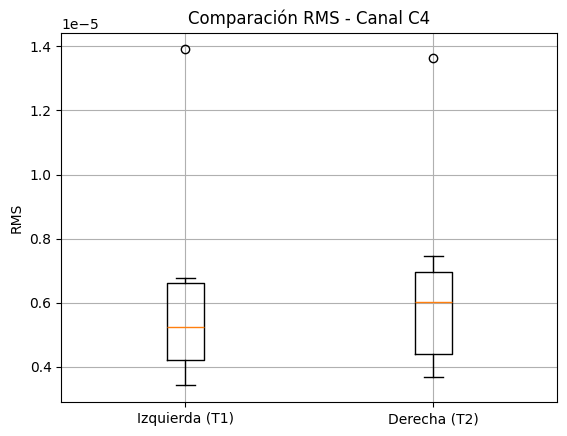

In [10]:
# Lista de canales significativos
canales_sig = df_significativos["Canal"].tolist()
print("\nCanales significativos:", canales_sig)

if not df_resultados.empty:
    canal_top = df_resultados.iloc[0]["Canal"]
    print("\nCanal más significativo:", canal_top)

    plt.figure()

    plt.boxplot(
        [df_izq[canal_top], df_der[canal_top]],
        labels=["Izquierda (T1)", "Derecha (T2)"]
    )

    plt.title(f"Comparación RMS - Canal {canal_top}")
    plt.ylabel("RMS")
    plt.grid()

    plt.show()
else:
    print("No hay datos para graficar.")